DELFI 6 summs

In [1]:
import numpy as np

import matplotlib.pyplot as plt

import glob


In [2]:
A = np.load('/pscratch/sd/j/joshuaw/DELFI_MAF_6_SUMMS/chain_02619.npz')['chain']
A = A.reshape(-1, A.shape[-1])

In [3]:
chains_test_coverage = []
params_test_coverage = []

files = glob.glob('/pscratch/sd/j/joshuaw/DELFI_MAF_6_SUMMS/chain_*.npz')
thin = 5

for file in files:
    dic = np.load(file)
    chain = dic['chain'][::thin,:,:]
    chains_test_coverage.append(chain.reshape(-1, chain.shape[-1]))
    params_test_coverage.append(dic['theta_true'])


_chains_test_coverage0 = np.stack(chains_test_coverage)
_params_test_coverage0 = np.stack(params_test_coverage)


In [4]:
w_mask = _params_test_coverage0[:, 2] > -1.0
params_test_coverage0 = _params_test_coverage0[w_mask]
chains_test_coverage0 = _chains_test_coverage0[w_mask]


In [5]:
chains_test_coverage0.shape,params_test_coverage0.shape

((2744, 25200, 3), (2744, 3))

Evaluating Target PDF & Proposal PDF (KDE Bandwidth: 0.1)...
Calculating Rejection Ratios...
Original samples: 2744
Accepted samples: 1714
Acceptance rate:  62.46%


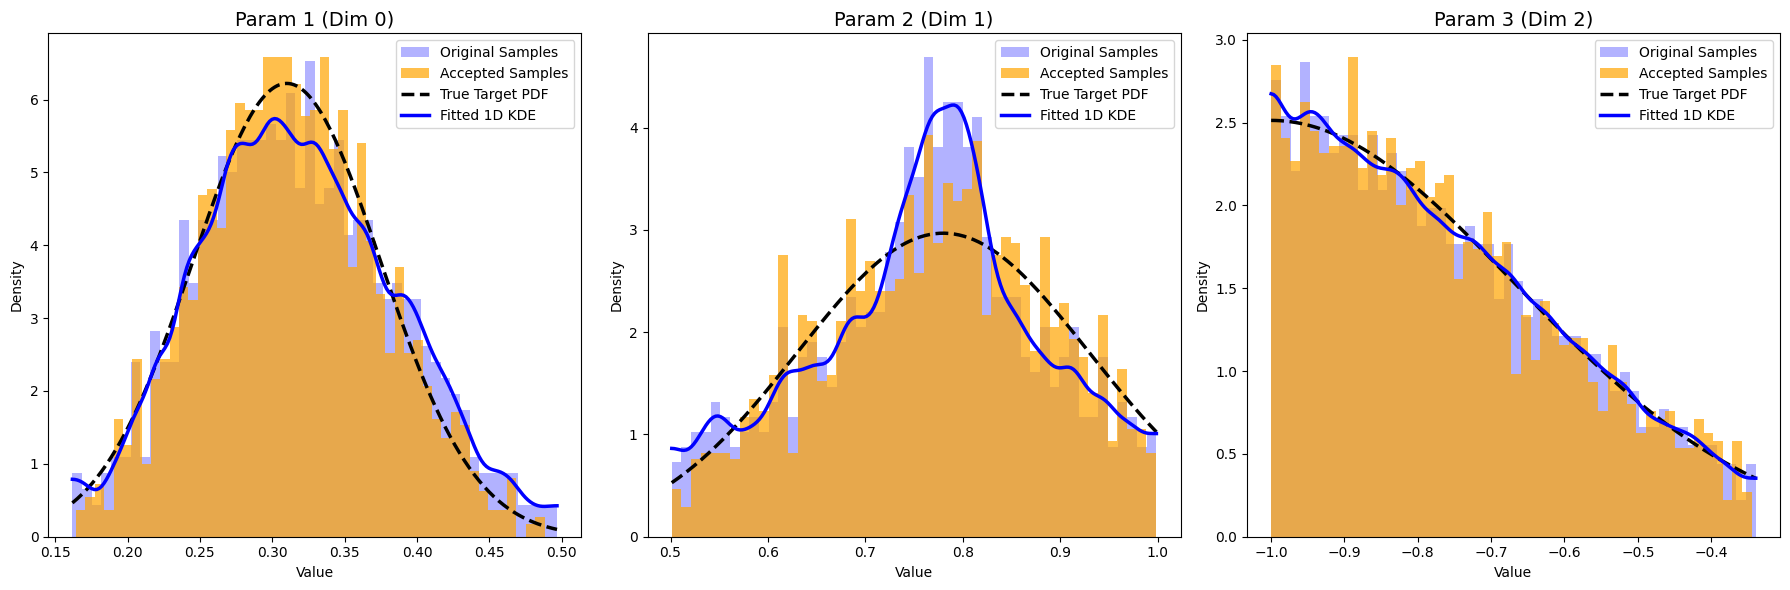

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, truncnorm

def evaluate_1d_reflected_kde(samples_1d, bounds_1d, bw_factor):
    """Fits and evaluates a 1D KDE with boundary reflection and explicit bandwidth."""
    # We pass bw_method to tighten the KDE fit around sharp peaks
    kde = gaussian_kde(samples_1d, bw_method=bw_factor)
    q_x = kde(samples_1d)
    
    lo, hi = bounds_1d
    q_x += kde(2 * lo - samples_1d)
    q_x += kde(2 * hi - samples_1d)
    
    return q_x, kde

def rejection_sample_uncorrelated(proposal_samples, target_mean, target_cov, bounds, bw_factor=1.0):
    n_samples, n_dims = proposal_samples.shape
    
    print(f"Evaluating Target PDF & Proposal PDF (KDE Bandwidth: {bw_factor})...")
    p_x = np.ones(n_samples)
    q_x = np.ones(n_samples)
    kdes = []
    
    for i in range(n_dims):
        lo, hi = bounds[i]
        mu = target_mean[i]
        sigma = np.sqrt(target_cov[i, i])
        
        # 1D Target PDF (Truncated Normal)
        a, b = (lo - mu) / sigma, (hi - mu) / sigma
        p_x *= truncnorm.pdf(proposal_samples[:, i], a, b, loc=mu, scale=sigma)
        
        # 1D Proposal PDF with tightened bandwidth
        q_x_1d, kde_1d = evaluate_1d_reflected_kde(proposal_samples[:, i], bounds[i], bw_factor)
        q_x *= q_x_1d
        kdes.append(kde_1d)
    
    print("Calculating Rejection Ratios...")
    ratios = p_x / q_x
    M = np.max(ratios)
    
    acceptance_probs = p_x / (M * q_x)
    u = np.random.uniform(0, 1, size=n_samples)
    accepted_indices = u <= acceptance_probs
    accepted_samples = proposal_samples[accepted_indices]
    
    print(f"Original samples: {n_samples}")
    print(f"Accepted samples: {len(accepted_samples)}")
    print(f"Acceptance rate:  {(len(accepted_samples) / n_samples) * 100:.2f}%")
    
    return accepted_indices, kdes

# ==========================================
# Execution & Plotting
# ==========================================
if __name__ == "__main__":

    # Assuming GST_params is loaded into your workspace
    unknown_samples = params_test_coverage0

    mus    = [0.31, 0.78, -1.0]
    sigmas = [0.065, 0.15,  1/3]
    
    target_mu = np.array(mus)
    target_cov = np.diag(np.square(sigmas))
    
    bounds = [
        (np.min(unknown_samples[:, 0]), np.max(unknown_samples[:, 0])),
        (np.min(unknown_samples[:, 1]), np.max(unknown_samples[:, 1])),
        (np.min(unknown_samples[:, 2]), np.max(unknown_samples[:, 2]))
    ]
    
    # Run with explicitly tighter bandwidth to stop oversmoothing
    accept_indices, kdes = rejection_sample_uncorrelated(
        proposal_samples=unknown_samples, 
        target_mean=target_mu, 
        target_cov=target_cov,
        bounds=bounds,
        bw_factor=0.1
    )
    final_samples = unknown_samples[accept_indices]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    param_names = ["Param 1 (Dim 0)", "Param 2 (Dim 1)", "Param 3 (Dim 2)"]

    for i in range(3):
        ax = axes[i]
        
        lo, hi = bounds[i]
        x_grid = np.linspace(lo, hi, 200)
        a, b = (lo - mus[i]) / sigmas[i], (hi - mus[i]) / sigmas[i]
        
        ax.hist(unknown_samples[:, i], bins=50, density=True, alpha=0.3, color='blue', label='Original Samples')
        ax.hist(final_samples[:, i], bins=50, density=True, alpha=0.7, color='orange', label='Accepted Samples')

        true_marginal = truncnorm.pdf(x_grid, a, b, loc=target_mu[i], scale=sigmas[i])
        ax.plot(x_grid, true_marginal, 'k--', linewidth=2.5, label='True Target PDF')

        kde_vals = kdes[i](x_grid) + kdes[i](2 * lo - x_grid) + kdes[i](2 * hi - x_grid)
        ax.plot(x_grid, kde_vals, 'b-', linewidth=2.5, label='Fitted 1D KDE')

        ax.set_title(param_names[i], fontsize=14)
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

In [7]:
tarp_chains = chains_test_coverage0[accept_indices]
tarp_params = params_test_coverage0[accept_indices]

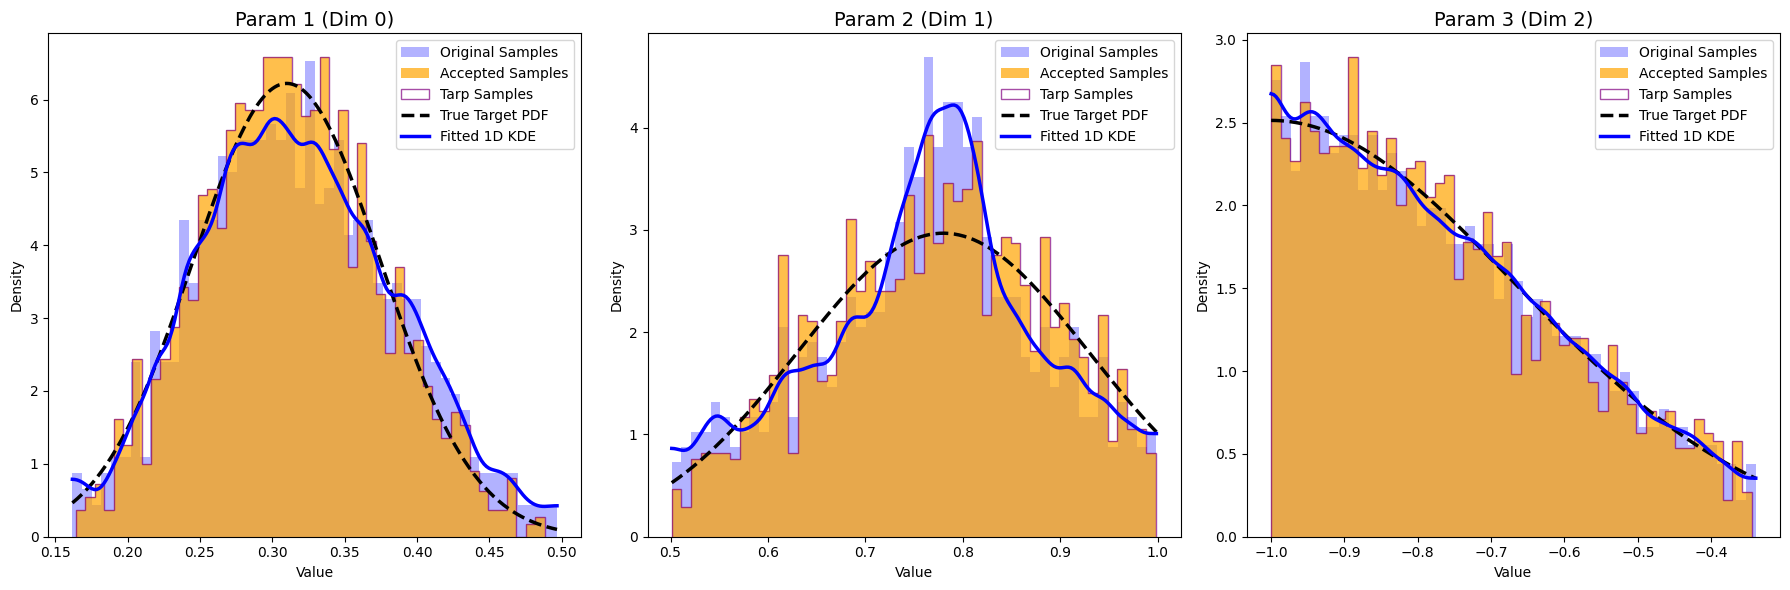

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
param_names = ["Param 1 (Dim 0)", "Param 2 (Dim 1)", "Param 3 (Dim 2)"]
for i in range(3):
    ax = axes[i]
        
    lo, hi = bounds[i]
    x_grid = np.linspace(lo, hi, 200)
    a, b = (lo - mus[i]) / sigmas[i], (hi - mus[i]) / sigmas[i]
        
    ax.hist(unknown_samples[:, i], bins=50, density=True, alpha=0.3, color='blue', label='Original Samples')
    ax.hist(final_samples[:, i], bins=50, density=True, alpha=0.7, color='orange', label='Accepted Samples')
    ax.hist(tarp_params[:, i], bins=50, density=True, alpha=0.7, color='purple', label='Tarp Samples', histtype='step')#, linewidth=3.0)

    true_marginal = truncnorm.pdf(x_grid, a, b, loc=target_mu[i], scale=sigmas[i])
    ax.plot(x_grid, true_marginal, 'k--', linewidth=2.5, label='True Target PDF')

    kde_vals = kdes[i](x_grid) + kdes[i](2 * lo - x_grid) + kdes[i](2 * hi - x_grid)
    ax.plot(x_grid, kde_vals, 'b-', linewidth=2.5, label='Fitted 1D KDE')



    ax.set_title(param_names[i], fontsize=14)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [13]:
import tarp

# np.random.seed(41)
upto = 2

ecp2, alpha2  = tarp.get_tarp_coverage(tarp_chains.transpose((1,0,2))[:, :, :upto], # \
                                      # + np.random.normal(size=chains_test_coverage0.transpose((1,0,2))[..., :upto].shape)*0.01, 
                                    theta=tarp_params[:, :upto],
                        bootstrap=True,
                        num_bootstrap=10,
                        seed=None,
                        norm=True,
                        num_alpha_bins=12,
                        metric='manhattan',
)

100%|██████████| 10/10 [00:51<00:00,  5.16s/it]


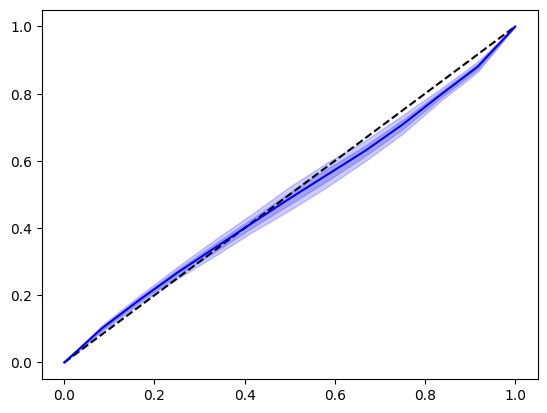

In [14]:
ecp_mean2 = np.mean(ecp2, axis=0)
ecp_std2 = np.std(ecp2, axis=0)
plt.plot([0, 1], [0, 1], ls='--', color='k')
plt.plot(alpha2, ecp_mean2, label='TARP', color='b')
plt.fill_between(alpha2, ecp_mean2 - ecp_std2, ecp_mean2 + ecp_std2,
                alpha=0.2, color='b')
plt.fill_between(alpha2, ecp_mean2 - 2 * ecp_std2, ecp_mean2 + 2 * ecp_std2,
                alpha=0.2, color='b')